In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [4]:
dataset1 = pd.read_csv('/content/drive/MyDrive/deep learning - Sheet1.csv')
X = dataset1[['input']].values
y = dataset1[['output']].values

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=33)

In [6]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [8]:
# Name:Saiprasath
# Register Number:212224230238
class NeuralNet(nn.Module):
  def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(1, 10)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(10, 1)
        self.history = {'loss': []}

  def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

In [9]:
ai_brain = NeuralNet()
criterion = nn.MSELoss()
optimizer = optim.Adam(ai_brain.parameters(), lr=0.01)

In [10]:
def train_model(ai_brain, X_train, y_train, criterion, optimizer, epochs=2000):
    # Write your code here
    for epoch in range(epochs):
        # Forward pass
        outputs = ai_brain(X_train)
        loss = criterion(outputs, y_train)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        ai_brain.history['loss'].append(loss.item())
        if epoch % 200 == 0:
            print(f'Epoch [{epoch}/{epochs}], Loss: {loss.item():.6f}')

In [11]:
train_model(ai_brain, X_train_tensor, y_train_tensor, criterion, optimizer)

Epoch [0/2000], Loss: 2857.653320
Epoch [200/2000], Loss: 766.052490
Epoch [400/2000], Loss: 718.197693
Epoch [600/2000], Loss: 703.812012
Epoch [800/2000], Loss: 702.456299
Epoch [1000/2000], Loss: 702.417542
Epoch [1200/2000], Loss: 702.417175
Epoch [1400/2000], Loss: 702.417175
Epoch [1600/2000], Loss: 702.417175
Epoch [1800/2000], Loss: 702.417175


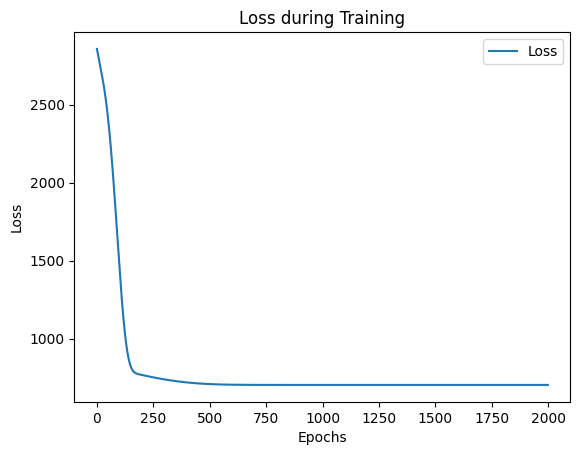

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

loss_df = pd.DataFrame(ai_brain.history['loss'], columns=['Loss'])
loss_df.plot()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss during Training")
plt.show()

In [13]:
X_n1_1 = torch.tensor([[9]], dtype=torch.float32)
prediction = ai_brain(torch.tensor(scaler.transform(X_n1_1), dtype=torch.float32)).item()
print(f'Prediction: {prediction}')

Prediction: 45.25020980834961
